> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** load two real moorings, combine onto a common time base, compare visually and via scatter plot, Pearson correlation.
>
> **To do:**
> - ~~Point at the edited files~~ (done).
> - **Write the sections** -- ~79 words of prose and 4 empty bullets.
> - Resolve the two-correlations question: 0.5953 (combined) vs 0.5918 (separately averaged). Cause is the time origin -- `combine_datasets` anchors all inputs to a shared origin, `time_average` called separately lets each anchor to its own first timestamp. Either cut one route or make the difference the teaching point.
> - The two records do not cover the same period (AT800 ends April 2022, AT200 October 2022) -- say so, since the correlation is over the overlap only.

<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">


# Comparing and correlating data from different instruments

We often want to compare or correlate records from different instruments -- for example, two moorings at different locations, or sensors at different depths. Before we can do that, we usually need to combine the datasets onto a common time base first.

So: combining is a means to an end here, not the point itself -- the goal is the comparison/correlation that follows.

*Notebook 9 of 10 in the series*  
[← 8. Sound speed](./08_initial_analysis_sound_speed.ipynb) · [10. Preparing data for publication →](./10_preparing_data_for_publication.ipynb)

In [1]:
from kval.data import moored
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib widget

___

## Combining the two records

- Why you would want two instruments on one time base.
- What `combine_datasets` does: averages onto a common interval and stacks along a new `INSTR` dimension.
- Why the two records need aligning at all (different sampling intervals, different start and end dates).

> ✏️ Placeholder -- prose needed.

In [2]:
ds1 = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT200_21_22_SBE37_20773_49m_edited.nc')
ds2 = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc')

In [3]:
ds_combined = moored.combine_datasets(ds1, ds2, interval = '1D', instr_names = ['AT200', 'AT800'])

In [4]:
ds_combined

<xarray.Dataset> Size: 43kB
Dimensions:                                 (INSTR: 2, TIME: 331)
Coordinates: (12/23)
  * INSTR                                   (INSTR) <U5 40B 'AT200' 'AT800'
  * TIME                                    (TIME) datetime64[ns] 3kB 2021-11...
    CNDC_sensor_calibration_date            (INSTR) <U10 80B '28-Apr-19' '201...
    CNDC_sensor_serial_number               (INSTR) object 16B '20773' None
    PRES_assumed_atmospheric_pressure_dbar  (INSTR) object 16B None 10.13
    PRES_sensor_calibration_date            (INSTR) <U10 80B '25-Apr-19' '201...
    ...                                      ...
    history                                 (INSTR) <U162 1kB '2021-11-07 - 2...
    instrument_model                        (INSTR) <U23 184B 'Sea-Bird SBE37...
    instrument_serial_number                (INSTR) <U21 168B '20773' '60595'
    sampling_details                        (INSTR) object 16B None 'One aver...
    source_file                             (INSTR) <U116 928B 'sbe37smp-rs23...
    time_coverage_resolution                (INSTR) <U20 160B 'P0000-00-00T00...
Data variables:
    CNDC                                    (INSTR, TIME) float64 5kB 31.13 ....
    DEPTH                                   (INSTR, TIME) float64 5kB nan ......
    PRES                                    (INSTR, TIME) float64 5kB 59.51 ....
    PSAL                                    (INSTR, TIME) float64 5kB 34.75 ....
    SPCNDC                                  (INSTR, TIME) float64 5kB nan ......
    SVEL                                    (INSTR, TIME) float64 5kB nan ......
    TEMP                                    (INSTR, TIME) float64 5kB 2.598 ....

___

## Comparing and correlating the two records

- What question the comparison answers: are these two sites seeing the same water, or different water?
- What you would expect given that AT800 sits in the Atlantic inflow and AT200 is shallower and shelf-side.

> ✏️ Placeholder -- prose needed. This is the "why", and it should come before the mechanics.

## Plot together

In [5]:
moored.plot(ds_combined)

## Scatter plot


In [6]:
TEMP_AT200 = ds_combined.TEMP.sel(INSTR = 'AT200')
TEMP_AT800 = ds_combined.TEMP.sel(INSTR = 'AT800')

Text(0, 0.5, 'TEMP, AT800 [°C]')

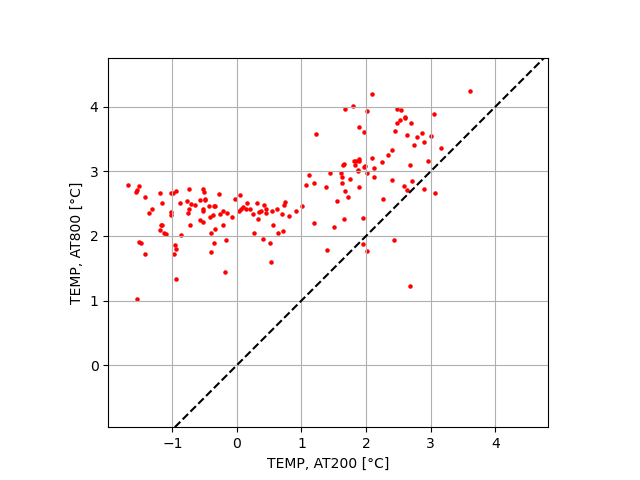

In [7]:

fig, ax = plt.subplots()
ax.scatter(TEMP_AT200, TEMP_AT800, s = 5, color = 'r')
ax.set_aspect('equal')
ax.grid()
ax.axline((-0.7, -0.7), (4.5, 4.5), color = 'k', ls = '--')
ax.set_xlabel('TEMP, AT200 [°C]')
ax.set_ylabel('TEMP, AT800 [°C]')

## Correlation

> ✏️ Placeholder -- interpret the number. A correlation near 0.6 between two moorings ~600 m apart in depth is neither trivially high nor low; say what it implies about how coupled the two depths are.

 Pearson correlation coefficient of the two time series 

In [8]:
xr.corr(TEMP_AT200, TEMP_AT800)

<xarray.DataArray 'TEMP' ()> Size: 8B
array(0.63487388)

> ✏️ **Review note** — these next two cells were sitting further up, under "Comparing and correlating", computing the same quantity a second way. I've moved them here so the two routes sit side by side, because they don't give the same answer: the combined-dataset route gave 0.5953 and this one gave 0.5918.

That isn't noise. `combine_datasets` anchors every dataset to a *shared* time origin so the daily bins line up exactly across instruments; calling `time_average` separately on each dataset lets each one anchor to its own first timestamp, so the two sets of daily means are averaging over slightly offset windows.

Pick one. Either drop these cells, or keep them and make the discrepancy the point -- it's a good, concrete illustration of why "put them on a common time base" is a real step and not bookkeeping.

In [9]:
ds1_daily = moored.time_average(ds1, '1D')
ds2_daily = moored.time_average(ds2, '1D')

In [10]:
xr.corr(ds1_daily.TEMP, ds2_daily.TEMP)

<xarray.DataArray 'TEMP' ()> Size: 8B
array(0.6218662)

___

**Next:** [10. Preparing data for publication →](./10_preparing_data_for_publication.ipynb)